<a href="https://colab.research.google.com/github/Sharvari02-deoke/Student_Attendance_System/blob/main/Credit_Score_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Load dataset
# Replace with your dataset path
df = pd.read_csv("Dataset.ipynb")

# Target column
target = "Creditworthy"

X = df.drop(columns=[target])
y = df[target]

# Encode target if needed
if y.dtype == "object":
    y = LabelEncoder().fit_transform(y)

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent"))
        ]), categorical_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print(f"\\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

    if hasattr(model, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        print("ROC-AUC:", roc_auc_score(y_test, y_prob))


       CREDIT SCORING MODEL — FULL PIPELINE

[1] Dataset generated: 2000 rows × 16 columns
    Creditworthy  : 1300 (65.0%)
    Non-creditworthy: 700 (35.0%)

[2] Feature Engineering ...
    Total features after engineering: 18

[3] Train/Test split: 1600 train | 400 test

[4] Training Models ...
    ✓ Logistic Regression — ROC-AUC: 0.9862  (CV: 0.9844 ± 0.0055)
    ✓ Decision Tree — ROC-AUC: 0.9077  (CV: 0.9026 ± 0.0176)
    ✓ Random Forest — ROC-AUC: 0.9676  (CV: 0.9649 ± 0.0105)
    ✓ Gradient Boosting — ROC-AUC: 0.9768  (CV: 0.9693 ± 0.0099)

[5] Model Performance Summary
---------------------------------------------------------------------------
Model                   Accuracy  Precision   Recall       F1   ROC-AUC
---------------------------------------------------------------------------
Logistic Regression       0.9425     0.9506   0.9615   0.9560    0.9862
Decision Tree             0.8650     0.9055   0.8846   0.8949    0.9077
Random Forest             0.9025     0.9300   0.9

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/credit_scoring_dashboard.png'

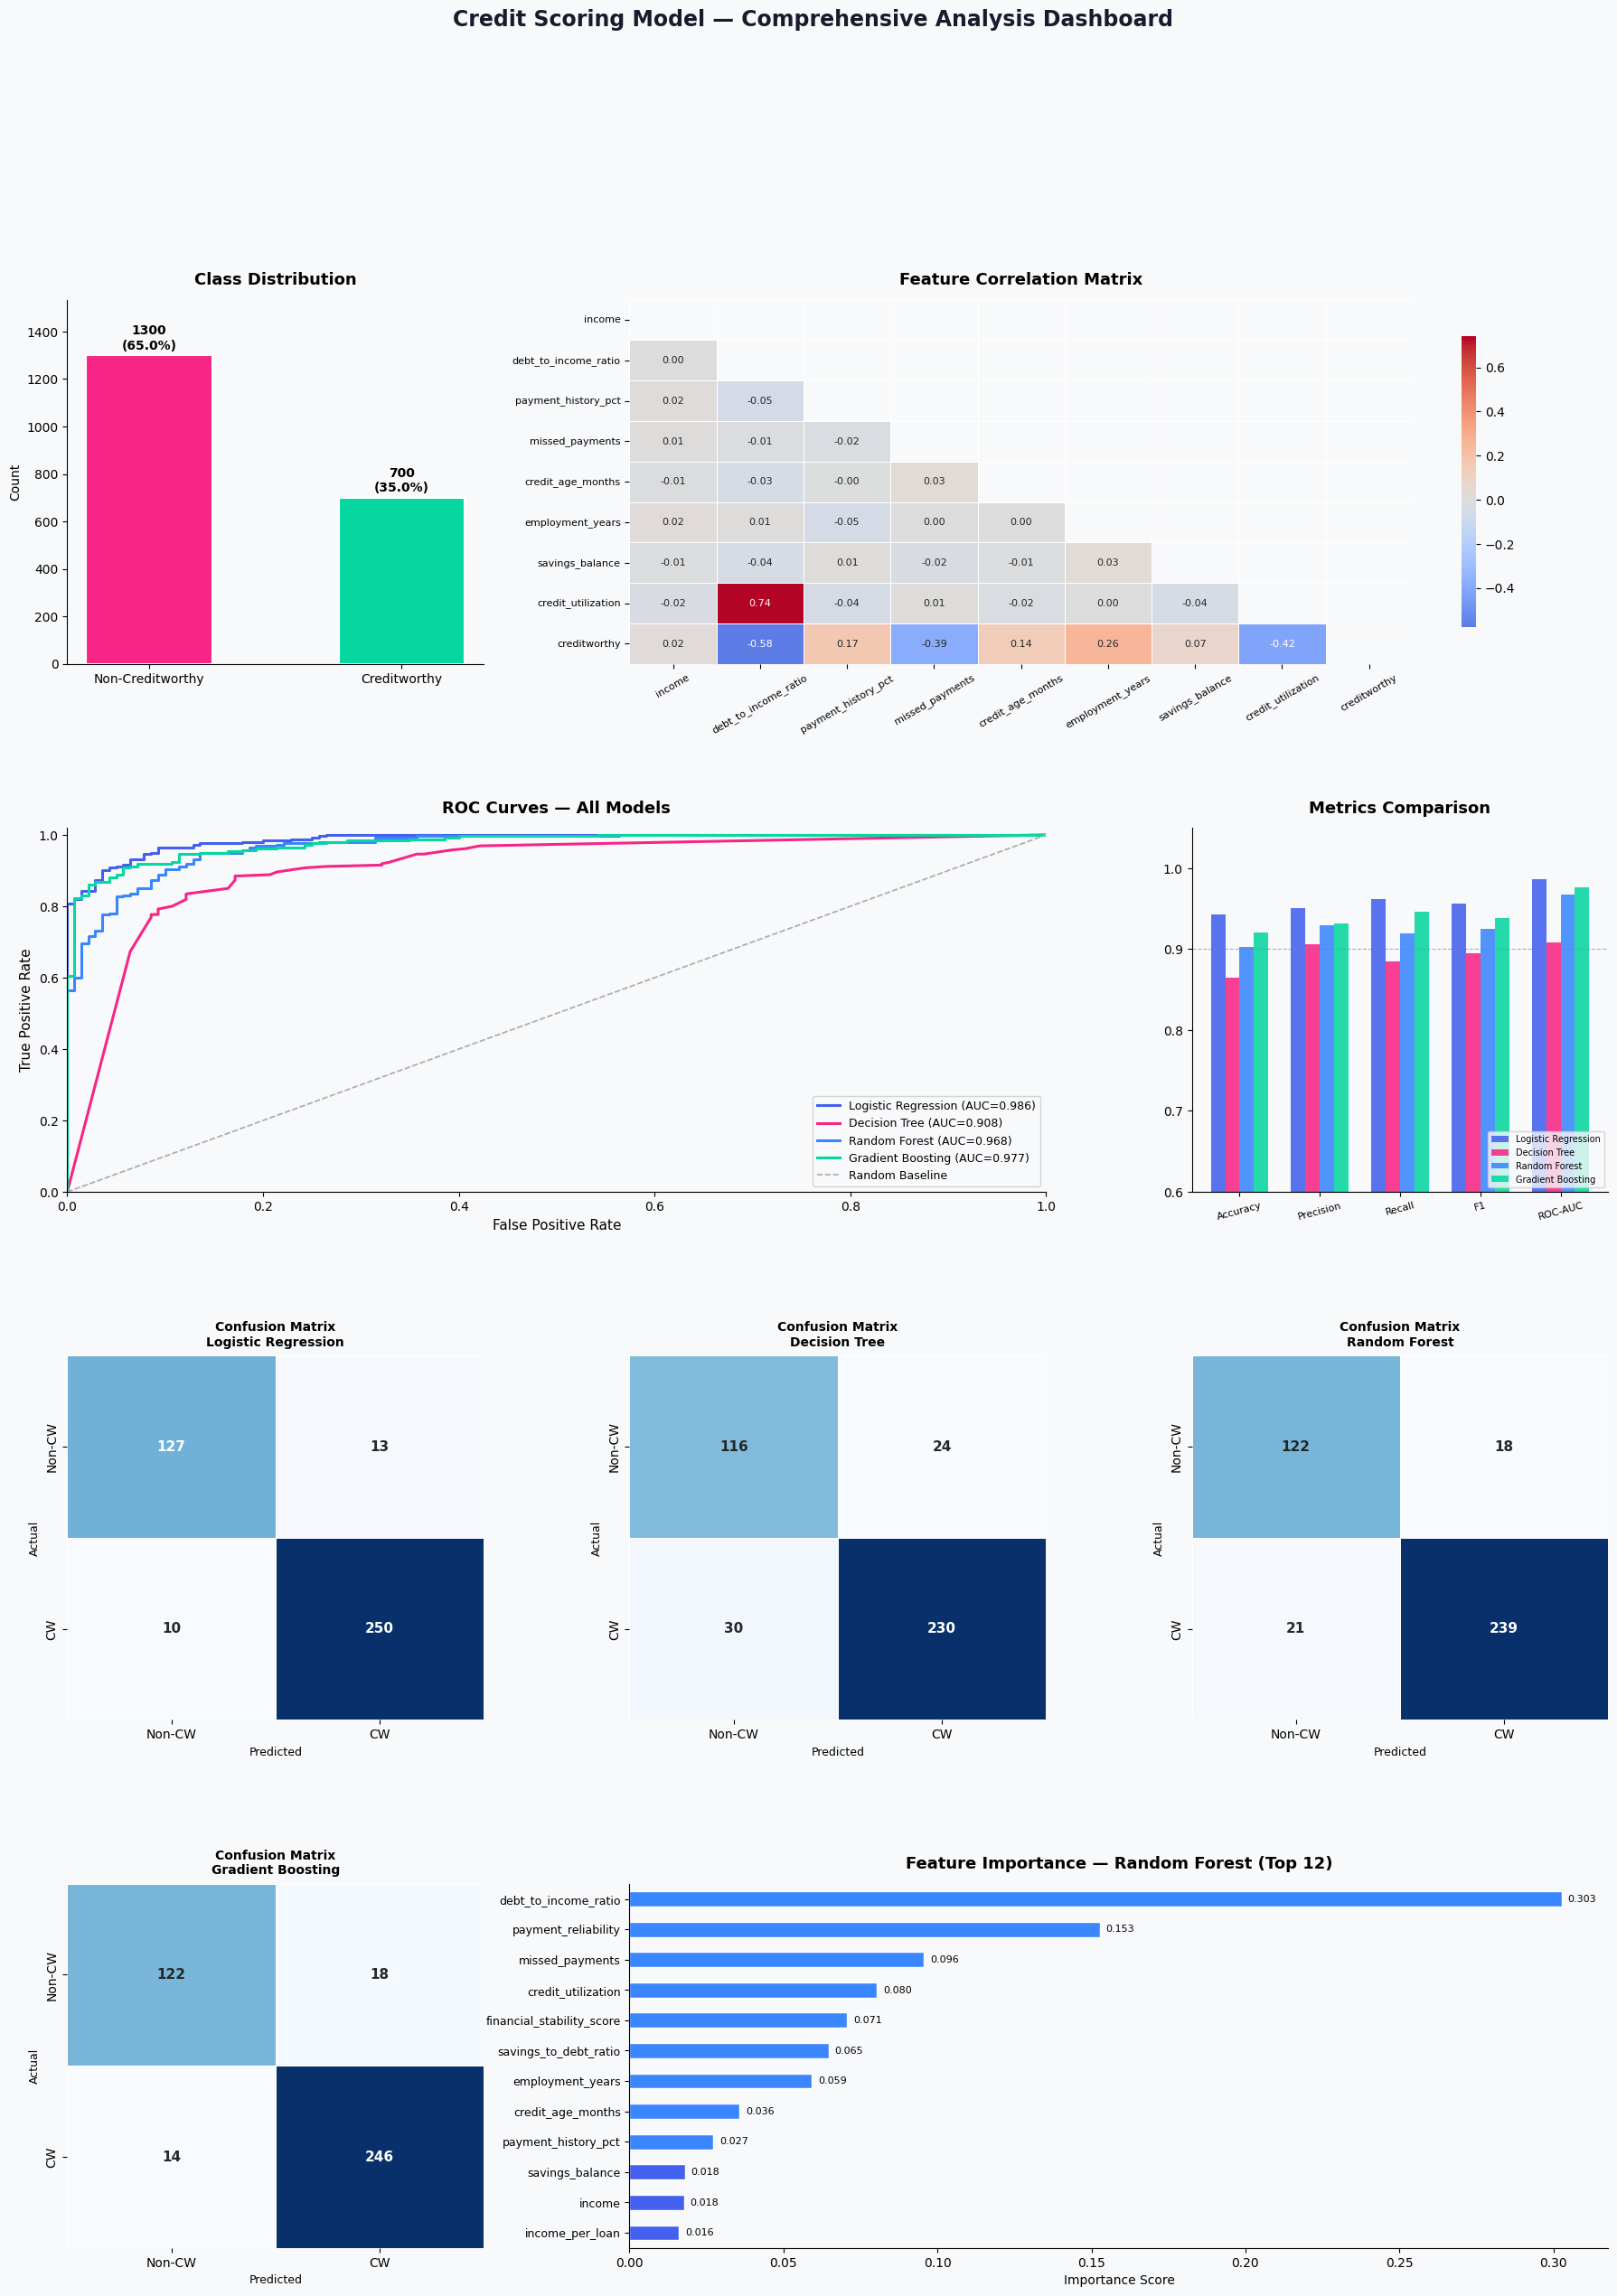

In [1]:
"""
Credit Scoring Model
====================
Predicts individual creditworthiness using financial history data.
Models: Logistic Regression, Decision Tree, Random Forest
Metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.utils import resample

# ─────────────────────────────────────────────
# 1. SYNTHETIC DATASET GENERATION
# ─────────────────────────────────────────────
np.random.seed(42)
N = 2000

def generate_credit_dataset(n=N):
    age           = np.random.randint(21, 70, n)
    income        = np.random.normal(55000, 20000, n).clip(15000, 200000)
    employment_years = np.random.randint(0, 35, n)
    num_credit_lines = np.random.randint(1, 10, n)
    credit_limit  = income * np.random.uniform(0.5, 3.0, n)
    current_debt  = credit_limit * np.random.uniform(0.05, 0.95, n)
    debt_to_income = current_debt / income
    payment_history = np.random.randint(60, 100, n)        # % on-time payments
    missed_payments = np.random.randint(0, 12, n)
    credit_age_months = np.random.randint(6, 300, n)
    num_hard_inquiries = np.random.randint(0, 8, n)
    loan_amount   = np.random.normal(15000, 10000, n).clip(1000, 80000)
    loan_purpose  = np.random.choice(['home', 'car', 'education', 'personal', 'business'], n)
    existing_loans = np.random.randint(0, 5, n)
    savings_balance = np.random.normal(10000, 8000, n).clip(0, 100000)

    # Credit score heuristic → creditworthy label
    score = (
        (payment_history - 60) * 0.40
        - debt_to_income * 25
        + (income / 5000) * 0.15
        + employment_years * 0.8
        - missed_payments * 3.5
        + (credit_age_months / 12) * 0.5
        - num_hard_inquiries * 1.2
        + (savings_balance / 2000) * 0.3
        + np.random.normal(0, 5, n)           # noise
    )
    threshold = np.percentile(score, 35)      # ~65% creditworthy
    creditworthy = (score >= threshold).astype(int)

    df = pd.DataFrame({
        'age': age,
        'income': income.astype(int),
        'employment_years': employment_years,
        'num_credit_lines': num_credit_lines,
        'credit_limit': credit_limit.astype(int),
        'current_debt': current_debt.astype(int),
        'debt_to_income_ratio': debt_to_income.round(4),
        'payment_history_pct': payment_history,
        'missed_payments': missed_payments,
        'credit_age_months': credit_age_months,
        'num_hard_inquiries': num_hard_inquiries,
        'loan_amount': loan_amount.astype(int),
        'loan_purpose': loan_purpose,
        'existing_loans': existing_loans,
        'savings_balance': savings_balance.astype(int),
        'creditworthy': creditworthy
    })
    return df

print("=" * 60)
print("       CREDIT SCORING MODEL — FULL PIPELINE")
print("=" * 60)

df = generate_credit_dataset()
print(f"\n[1] Dataset generated: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"    Creditworthy  : {df['creditworthy'].sum()} ({df['creditworthy'].mean()*100:.1f}%)")
print(f"    Non-creditworthy: {(1-df['creditworthy']).sum()} ({(1-df['creditworthy']).mean()*100:.1f}%)")

# ─────────────────────────────────────────────
# 2. FEATURE ENGINEERING
# ─────────────────────────────────────────────
print("\n[2] Feature Engineering ...")

le = LabelEncoder()
df['loan_purpose_enc'] = le.fit_transform(df['loan_purpose'])

df['credit_utilization']        = df['current_debt'] / df['credit_limit']
df['income_per_loan']           = df['income'] / (df['loan_amount'] + 1)
df['savings_to_debt_ratio']     = df['savings_balance'] / (df['current_debt'] + 1)
df['payment_reliability']       = df['payment_history_pct'] / (df['missed_payments'] + 1)
df['financial_stability_score'] = (
    df['employment_years'] * 0.3
    + (df['income'] / 10000) * 0.4
    + (df['savings_balance'] / 5000) * 0.3
)

FEATURES = [
    'age', 'income', 'employment_years', 'num_credit_lines',
    'debt_to_income_ratio', 'payment_history_pct', 'missed_payments',
    'credit_age_months', 'num_hard_inquiries', 'loan_amount',
    'loan_purpose_enc', 'existing_loans', 'savings_balance',
    'credit_utilization', 'income_per_loan', 'savings_to_debt_ratio',
    'payment_reliability', 'financial_stability_score'
]

X = df[FEATURES]
y = df['creditworthy']

print(f"    Total features after engineering: {len(FEATURES)}")

# ─────────────────────────────────────────────
# 3. TRAIN / TEST SPLIT + SCALING
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n[3] Train/Test split: {len(X_train)} train | {len(X_test)} test")

# ─────────────────────────────────────────────
# 4. MODEL TRAINING
# ─────────────────────────────────────────────
print("\n[4] Training Models ...")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    "Decision Tree":       DecisionTreeClassifier(max_depth=8, min_samples_split=20, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=10,
                                                   min_samples_split=10, random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                                       max_depth=5, random_state=42),
}

results   = {}
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    X_tr = X_train_sc if name == "Logistic Regression" else X_train
    X_te = X_test_sc  if name == "Logistic Regression" else X_test
    X_cv = X_train_sc if name == "Logistic Regression" else X_train

    model.fit(X_tr, y_train)
    y_pred      = model.predict(X_te)
    y_prob      = model.predict_proba(X_te)[:, 1]
    cv_scores   = cross_val_score(model, X_cv, y_train, cv=cv, scoring='roc_auc')

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_prob),
        'cv_roc_auc_mean': cv_scores.mean(),
        'cv_roc_auc_std':  cv_scores.std(),
    }
    print(f"    ✓ {name} — ROC-AUC: {results[name]['roc_auc']:.4f}  "
          f"(CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f})")

# ─────────────────────────────────────────────
# 5. PRINT METRICS TABLE
# ─────────────────────────────────────────────
print("\n[5] Model Performance Summary")
print("-" * 75)
print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9}")
print("-" * 75)
for name, r in results.items():
    print(f"{name:<22} {r['accuracy']:>9.4f} {r['precision']:>10.4f} "
          f"{r['recall']:>8.4f} {r['f1']:>8.4f} {r['roc_auc']:>9.4f}")
print("-" * 75)

best_model_name = max(results, key=lambda k: results[k]['roc_auc'])
print(f"\n  ★  Best model by ROC-AUC: {best_model_name} "
      f"({results[best_model_name]['roc_auc']:.4f})")

# ─────────────────────────────────────────────
# 6. VISUALIZATIONS
# ─────────────────────────────────────────────
print("\n[6] Generating visualizations ...")

COLORS = {
    "Logistic Regression": "#4361EE",
    "Decision Tree":       "#F72585",
    "Random Forest":       "#3A86FF",
    "Gradient Boosting":   "#06D6A0",
}
PALETTE = list(COLORS.values())

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': '#F8F9FB',
    'axes.facecolor': '#F8F9FB',
})

fig = plt.figure(figsize=(22, 28))
fig.patch.set_facecolor('#F8F9FB')
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── (A) Class Distribution ──
ax_a = fig.add_subplot(gs[0, 0])
counts = y.value_counts()
bars = ax_a.bar(['Non-Creditworthy', 'Creditworthy'], counts.values,
                color=['#F72585', '#06D6A0'], edgecolor='white', linewidth=1.5, width=0.5)
for bar, cnt in zip(bars, counts.values):
    ax_a.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
              f'{cnt}\n({cnt/len(y)*100:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax_a.set_title('Class Distribution', fontsize=13, fontweight='bold', pad=12)
ax_a.set_ylabel('Count')
ax_a.set_ylim(0, counts.max() * 1.18)

# ── (B) Feature Correlation Heatmap ──
ax_b = fig.add_subplot(gs[0, 1:])
key_feats = ['income', 'debt_to_income_ratio', 'payment_history_pct',
             'missed_payments', 'credit_age_months', 'employment_years',
             'savings_balance', 'credit_utilization', 'creditworthy']
corr = df[key_feats].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax_b, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
ax_b.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
ax_b.tick_params(axis='x', rotation=30, labelsize=8)
ax_b.tick_params(axis='y', rotation=0,  labelsize=8)

# ── (C) ROC Curves ──
ax_c = fig.add_subplot(gs[1, :2])
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax_c.plot(fpr, tpr, color=COLORS[name], lw=2.2,
              label=f"{name} (AUC={r['roc_auc']:.3f})")
ax_c.plot([0,1],[0,1],'--', color='#AAAAAA', lw=1.2, label='Random Baseline')
ax_c.fill_between([0,1],[0,1],[0,1], alpha=0.05, color='gray')
ax_c.set_xlabel('False Positive Rate', fontsize=11)
ax_c.set_ylabel('True Positive Rate', fontsize=11)
ax_c.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold', pad=12)
ax_c.legend(fontsize=9, loc='lower right')
ax_c.set_xlim([0,1]); ax_c.set_ylim([0,1.02])

# ── (D) Metrics Bar Chart ──
ax_d = fig.add_subplot(gs[1, 2])
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metric_names))
width = 0.18
for i, (name, r) in enumerate(results.items()):
    vals = [r['accuracy'], r['precision'], r['recall'], r['f1'], r['roc_auc']]
    ax_d.bar(x + i*width, vals, width, label=name, color=COLORS[name], alpha=0.88)
ax_d.set_xticks(x + width*1.5)
ax_d.set_xticklabels(metric_names, fontsize=8, rotation=15)
ax_d.set_ylim(0.6, 1.05)
ax_d.set_title('Metrics Comparison', fontsize=13, fontweight='bold', pad=12)
ax_d.legend(fontsize=7, loc='lower right')
ax_d.axhline(0.9, color='gray', linestyle='--', lw=0.8, alpha=0.6)

# ── (E) Confusion Matrices ──
model_list = list(results.items())
for idx, (name, r) in enumerate(model_list):
    ax = fig.add_subplot(gs[2, idx % 3] if idx < 3 else gs[3, 0])
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-CW', 'CW'], yticklabels=['Non-CW', 'CW'],
                linewidths=0.5, cbar=False, annot_kws={'size': 11, 'weight': 'bold'})
    ax.set_title(f'Confusion Matrix\n{name}', fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)

# ── (F) Feature Importance — Random Forest ──
ax_f = fig.add_subplot(gs[3, 1:])
rf_model   = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
top_feats   = importances.tail(12)
colors_fi   = ['#4361EE' if v < importances.median() else '#3A86FF' for v in top_feats.values]
top_feats.plot(kind='barh', ax=ax_f, color=colors_fi, edgecolor='white')
ax_f.set_title('Feature Importance — Random Forest (Top 12)', fontsize=13, fontweight='bold', pad=12)
ax_f.set_xlabel('Importance Score', fontsize=10)
ax_f.tick_params(axis='y', labelsize=9)
for i, (val, patch) in enumerate(zip(top_feats.values, ax_f.patches)):
    ax_f.text(val + 0.002, patch.get_y() + patch.get_height()/2,
              f'{val:.3f}', va='center', fontsize=8)

fig.suptitle('Credit Scoring Model — Comprehensive Analysis Dashboard',
             fontsize=17, fontweight='bold', y=0.995, color='#1A1A2E')

plt.savefig('/mnt/user-data/outputs/credit_scoring_dashboard.png',
            dpi=150, bbox_inches='tight', facecolor='#F8F9FB')
print("    ✓ Dashboard saved.")

# ─────────────────────────────────────────────
# 7. CREDIT SCORE FUNCTION
# ─────────────────────────────────────────────
print("\n[7] Credit Score Prediction Function")

def predict_credit_score(applicant: dict) -> dict:
    """Score a new applicant (0–850 FICO-like scale)."""
    row = pd.DataFrame([applicant])
    row['loan_purpose_enc']         = le.transform([applicant.get('loan_purpose','personal')])[0]
    row['debt_to_income_ratio']     = row['current_debt'] / row['income']
    row['credit_utilization']       = row['current_debt'] / row['credit_limit']
    row['income_per_loan']          = row['income'] / (row['loan_amount'] + 1)
    row['savings_to_debt_ratio']    = row['savings_balance'] / (row['current_debt'] + 1)
    row['payment_reliability']      = row['payment_history_pct'] / (row['missed_payments'] + 1)
    row['financial_stability_score']= (
        row['employment_years']*0.3 + (row['income']/10000)*0.4 + (row['savings_balance']/5000)*0.3
    )
    X_new = row[FEATURES]
    X_new_sc = scaler.transform(X_new)

    proba = results['Random Forest']['model'].predict_proba(X_new)[0][1]
    credit_score = int(300 + proba * 550)   # map 0-1 → 300-850

    if credit_score >= 750:   grade, decision = 'A', 'APPROVED  — Excellent'
    elif credit_score >= 700: grade, decision = 'B', 'APPROVED  — Good'
    elif credit_score >= 650: grade, decision = 'C', 'CONDITIONAL — Fair'
    elif credit_score >= 600: grade, decision = 'D', 'REVIEW    — Poor'
    else:                     grade, decision = 'F', 'DECLINED  — Very Poor'

    return {'credit_score': credit_score, 'grade': grade,
            'decision': decision, 'probability': round(proba, 4)}

# Sample applicants
applicants = [
    dict(age=35, income=75000, employment_years=8, num_credit_lines=4,
         credit_limit=30000, current_debt=6000, payment_history_pct=97,
         missed_payments=0, credit_age_months=120, num_hard_inquiries=1,
         loan_amount=12000, loan_purpose='home', existing_loans=1, savings_balance=25000),
    dict(age=27, income=32000, employment_years=2, num_credit_lines=2,
         credit_limit=8000, current_debt=7200, payment_history_pct=72,
         missed_payments=4, credit_age_months=30, num_hard_inquiries=6,
         loan_amount=15000, loan_purpose='personal', existing_loans=3, savings_balance=500),
    dict(age=45, income=120000, employment_years=18, num_credit_lines=7,
         credit_limit=80000, current_debt=15000, payment_history_pct=99,
         missed_payments=0, credit_age_months=240, num_hard_inquiries=0,
         loan_amount=40000, loan_purpose='business', existing_loans=1, savings_balance=60000),
]

labels = ["Moderate-Risk Applicant", "High-Risk Applicant", "Low-Risk Applicant"]
print("\n" + "─" * 55)
for label, app in zip(labels, applicants):
    res = predict_credit_score(app)
    print(f"  {label}")
    print(f"    Credit Score : {res['credit_score']}  (Grade {res['grade']})")
    print(f"    Decision     : {res['decision']}")
    print(f"    Probability  : {res['probability']:.2%}")
    print()

print("=" * 60)
print("  Pipeline complete.")
print("=" * 60)